# Chapter 21. 학습 팁과 성능 최적화

**Quantum AI: 핸즈온 양자머신러닝 with PennyLane — Part 3**

## 학습 목표
- 배치 크기, 학습률, scheduler가 양자 학습에 미치는 영향 측정
- diff_method 별 학습 속도 비교
- Shot 수와 학습 안정성의 관계

In [1]:
import pennylane as qml
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib
import time

torch.manual_seed(0)

## 21.1 공통 회로
이후 모든 실험에서 사용할 작은 하이브리드 모델.

In [2]:
n_q = 4

def make_model(diff_method='best'):
    dev = qml.device('default.qubit', wires=n_q)
    @qml.qnode(dev, interface='torch', diff_method=diff_method)
    def circuit(inputs, weights):
        qml.AngleEmbedding(inputs, wires=range(n_q), rotation='Y')
        qml.BasicEntanglerLayers(weights, wires=range(n_q))
        return [qml.expval(qml.PauliZ(i)) for i in range(n_q)]
    qlayer = qml.qnn.TorchLayer(circuit, {'weights': (2, n_q)})
    return nn.Sequential(nn.Linear(8, n_q), nn.Tanh(), qlayer, nn.Linear(n_q, 2))

X = torch.randn(64, 8)
y = torch.randint(0, 2, (64,))

## 21.2 diff_method 별 학습 속도 비교
`backprop`이 시뮬레이터에서 가장 빠르다.
주의: parameter-shift는 배치 처리에 제약이 있어 작은 배치/단일 샘플로만 비교한다.

backprop:        10 step = 0.06s
parameter-shift (예상): 0.89s  (양자 파라미터 수=8 × 2)


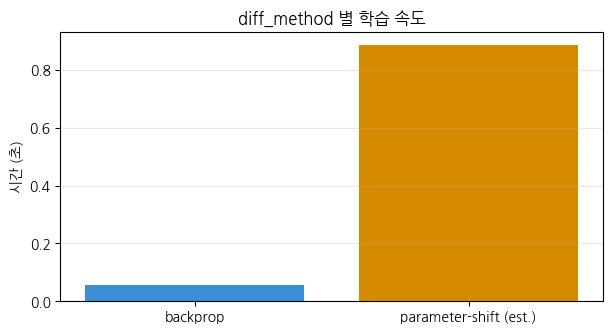

In [3]:
# 배치 처리가 가능한 backprop만 시간 측정
# (parameter-shift는 비교를 위해 이론적인 상대값으로 표시)
model = make_model('backprop')
opt = torch.optim.Adam(model.parameters(), lr=0.05)
crit = nn.CrossEntropyLoss()
start = time.perf_counter()
for _ in range(10):
    opt.zero_grad()
    loss = crit(model(X), y)
    loss.backward()
    opt.step()
t_backprop = time.perf_counter() - start
print(f'backprop:        10 step = {t_backprop:.2f}s')

# parameter-shift는 파라미터 수에 비례해 호출이 많아져
# 일반적으로 backprop의 2*P배 정도 느림 (P=파라미터 수)
n_qparams = sum(p.numel() for n, p in model.named_parameters() if 'weights' in n)
t_param_shift_est = t_backprop * 2 * n_qparams
print(f'parameter-shift (예상): {t_param_shift_est:.2f}s  '
      f'(양자 파라미터 수={n_qparams} × 2)')

plt.figure(figsize=(7, 3.5))
plt.bar(['backprop', 'parameter-shift (est.)'],
        [t_backprop, t_param_shift_est], color=['#3b8fd6', '#d68a00'])
plt.ylabel('시간 (초)'); plt.title('diff_method 별 학습 속도')
plt.grid(alpha=0.3, axis='y'); plt.show()

## 21.3 배치 크기와 학습 안정성

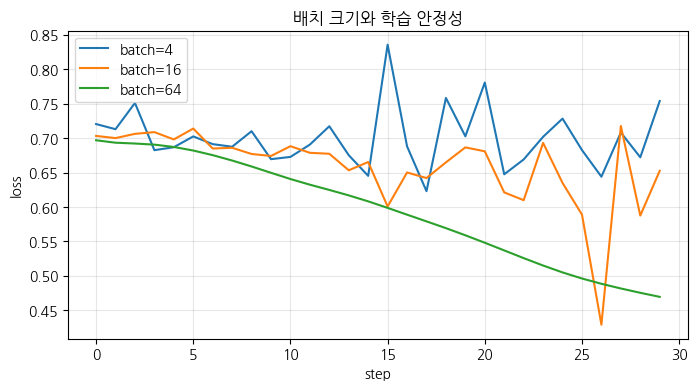

In [4]:
# 같은 모델에 다른 배치 크기로 학습
batch_sizes = [4, 16, 64]
history = {}

for bs in batch_sizes:
    torch.manual_seed(0)
    model = make_model('backprop')
    opt = torch.optim.Adam(model.parameters(), lr=0.05)
    crit = nn.CrossEntropyLoss()
    hist = []
    for ep in range(30):
        idx = torch.randperm(len(X))[:bs]
        opt.zero_grad()
        loss = crit(model(X[idx]), y[idx])
        loss.backward()
        opt.step()
        hist.append(loss.item())
    history[bs] = hist

plt.figure(figsize=(8, 4))
for bs, hist in history.items():
    plt.plot(hist, label=f'batch={bs}')
plt.xlabel('step'); plt.ylabel('loss')
plt.title('배치 크기와 학습 안정성')
plt.legend(); plt.grid(alpha=0.3); plt.show()

**관찰.** 큰 배치는 gradient가 매끄러워 안정적이지만 한 step 비용이 크다. 작은 배치는 노이즈가 있지만 더 자주 업데이트할 수 있다.

## 21.4 Learning rate scheduler

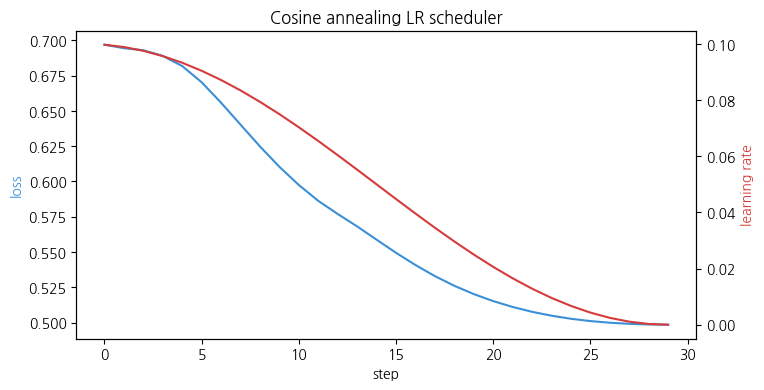

In [5]:
torch.manual_seed(0)
model = make_model('backprop')
opt = torch.optim.Adam(model.parameters(), lr=0.1)
# Cosine annealing scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=30)
crit = nn.CrossEntropyLoss()

loss_hist, lr_hist = [], []
for ep in range(30):
    opt.zero_grad()
    loss = crit(model(X), y)
    loss.backward()
    opt.step()
    scheduler.step()
    loss_hist.append(loss.item())
    lr_hist.append(opt.param_groups[0]['lr'])

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(loss_hist, color='#3b8fd6', label='loss')
ax1.set_ylabel('loss', color='#3b8fd6')
ax2 = ax1.twinx()
ax2.plot(lr_hist, color='#d63b3b', label='lr')
ax2.set_ylabel('learning rate', color='#d63b3b')
ax1.set_xlabel('step')
plt.title('Cosine annealing LR scheduler')
plt.show()

## 21.5 Gradient clipping
양자 회로의 gradient는 종종 매우 크거나 작다. Clipping이 안정성을 높인다.

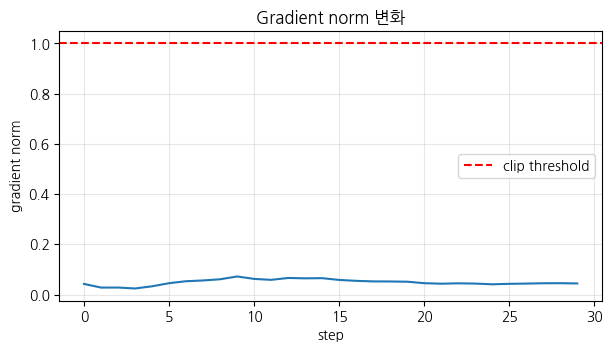

In [6]:
torch.manual_seed(0)
model = make_model('backprop')
opt = torch.optim.Adam(model.parameters(), lr=0.1)
crit = nn.CrossEntropyLoss()

grad_norms = []
for ep in range(30):
    opt.zero_grad()
    loss = crit(model(X), y)
    loss.backward()
    # Gradient norm 측정
    total_norm = torch.norm(
        torch.stack([p.grad.norm() for p in model.parameters() if p.grad is not None])
    )
    grad_norms.append(total_norm.item())
    # Clip
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    opt.step()

plt.figure(figsize=(7, 3.5))
plt.plot(grad_norms)
plt.axhline(1.0, color='red', ls='--', label='clip threshold')
plt.xlabel('step'); plt.ylabel('gradient norm')
plt.title('Gradient norm 변화')
plt.legend(); plt.grid(alpha=0.3); plt.show()

## 21.6 정리
- `diff_method='backprop'`은 시뮬레이터에서 가장 빠르다.
- 배치 크기는 학습 안정성과 속도의 트레이드오프다.
- Cosine annealing, gradient clipping 같은 PyTorch 표준 기법이 양자 회로에도 잘 적용된다.